# 05 — Backtest Analysis

Analyze the portfolio backtest results: equity curves, drawdowns, regime-conditional
performance, position sizing behavior, and benchmark comparison.

**Prerequisites:** Run `make backtest` so that `runs/liquid_core_v5/outputs/backtest/` is populated.

In [12]:
import sys
import os
from pathlib import Path
if Path(os.getcwd()).name == 'notebooks':
    os.chdir('..')
sys.path.append(os.path.abspath('src'))
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

from volregime.utils.config import load_config
from volregime.evaluation.economic_metrics import compute_economic_metrics
from volregime.portfolio.regime_rules import REGIME_INT_TO_NAME

cfg = load_config()
# Change version: 'runs/liquid_core_v4/outputs' for V4
bt_dir = Path('runs/liquid_core_v5/outputs/backtest')
print(f"bt_dir exists: {bt_dir.exists()}")
print(f"REGIME_INT_TO_NAME: {REGIME_INT_TO_NAME}")

bt_dir exists: True
REGIME_INT_TO_NAME: {0: 'bull_quiet', 1: 'bull_volatile', 2: 'bear_quiet', 3: 'bear_volatile', 4: 'sideways_quiet', 5: 'sideways_volatile'}


## 1. Load Backtest Results

In [13]:
# Equity curve — load WITHOUT index_col to keep 'date' as a regular column
eq_path = bt_dir / 'equity_curve.csv'
equity_df = None
if eq_path.exists():
    equity_df = pd.read_csv(eq_path, parse_dates=['date'])
    print(f"Backtest: {len(equity_df)} trading days")
    print(f"Date range: {equity_df['date'].min().date()} -> {equity_df['date'].max().date()}")
    print(f"Columns: {list(equity_df.columns)}")
    print(equity_df.head())
else:
    print(f"No equity curve found at {eq_path}. Run `make backtest` first.")

Backtest: 1764 trading days
Date range: 2018-04-12 -> 2025-04-22
Columns: ['date', 'equity', 'weight', 'underlying_ret', 'strategy_ret', 'cost', 'drawdown', 'regime_name', 'sigma_hat', 'p_crisis', 'n_symbols']
        date    equity    weight  underlying_ret  strategy_ret      cost  \
0 2018-04-12  0.999555  0.635569       -0.007490     -0.000445  0.000445   
1 2018-04-13  1.004331  0.643417        0.007482      0.004778  0.000450   
2 2018-04-16  1.007864  1.471502        0.006205      0.003518  0.001030   
3 2018-04-17  1.010756  1.456522        0.001992      0.002869  0.001020   
4 2018-04-18  1.010831  1.482042       -0.000038      0.000075  0.001037   

   drawdown    regime_name  sigma_hat  p_crisis  n_symbols  
0       0.0  bull_volatile   0.182358       0.0          7  
1       0.0  bull_volatile   0.180045       0.0          7  
2       0.0     bull_quiet   0.176952       0.0          7  
3       0.0     bull_quiet   0.181940       0.0          7  
4       0.0     bull_quiet  

In [14]:
# Summary metrics
summary = None
summary_path = bt_dir / 'summary.json'
if summary_path.exists():
    with open(summary_path) as f:
        summary = json.load(f)

    print("Strategy Summary:")
    for k, v in summary.items():
        if k == 'per_regime':
            continue
        print(f"  {k}: {v}")

# Benchmark metrics
bmark_summary = None
bmark_path = bt_dir / 'benchmark_summary.json'
if bmark_path.exists():
    with open(bmark_path) as f:
        bmark_summary = json.load(f)

    print("\nBenchmark Summaries:")
    for bname, bmetrics in bmark_summary.items():
        print(f"  {bname}: Sharpe={bmetrics.get('sharpe', 'N/A')}, "
              f"Return={bmetrics.get('ann_return_pct', 'N/A')}%, "
              f"MaxDD={bmetrics.get('max_drawdown_pct', 'N/A')}%")

Strategy Summary:
  ann_return_pct: 8.99
  ann_vol_pct: 16.196
  sharpe: 0.555
  sortino: 0.6635
  max_drawdown_pct: -27.372
  calmar: 0.3284
  total_return_pct: 71.056
  n_trading_days: 1764
  positive_days_pct: 49.43
  turnover_ann: 17.385
  avg_weight: 0.8715
  weight_std: 0.4676
  vol_target_tracking: 0.5399

Benchmark Summaries:
  buy_and_hold: Sharpe=0.4226, Return=10.531%, MaxDD=-40.659%
  inverse_vol: Sharpe=0.5246, Return=14.285%, MaxDD=-40.753%


## 2. Equity Curve and Drawdown

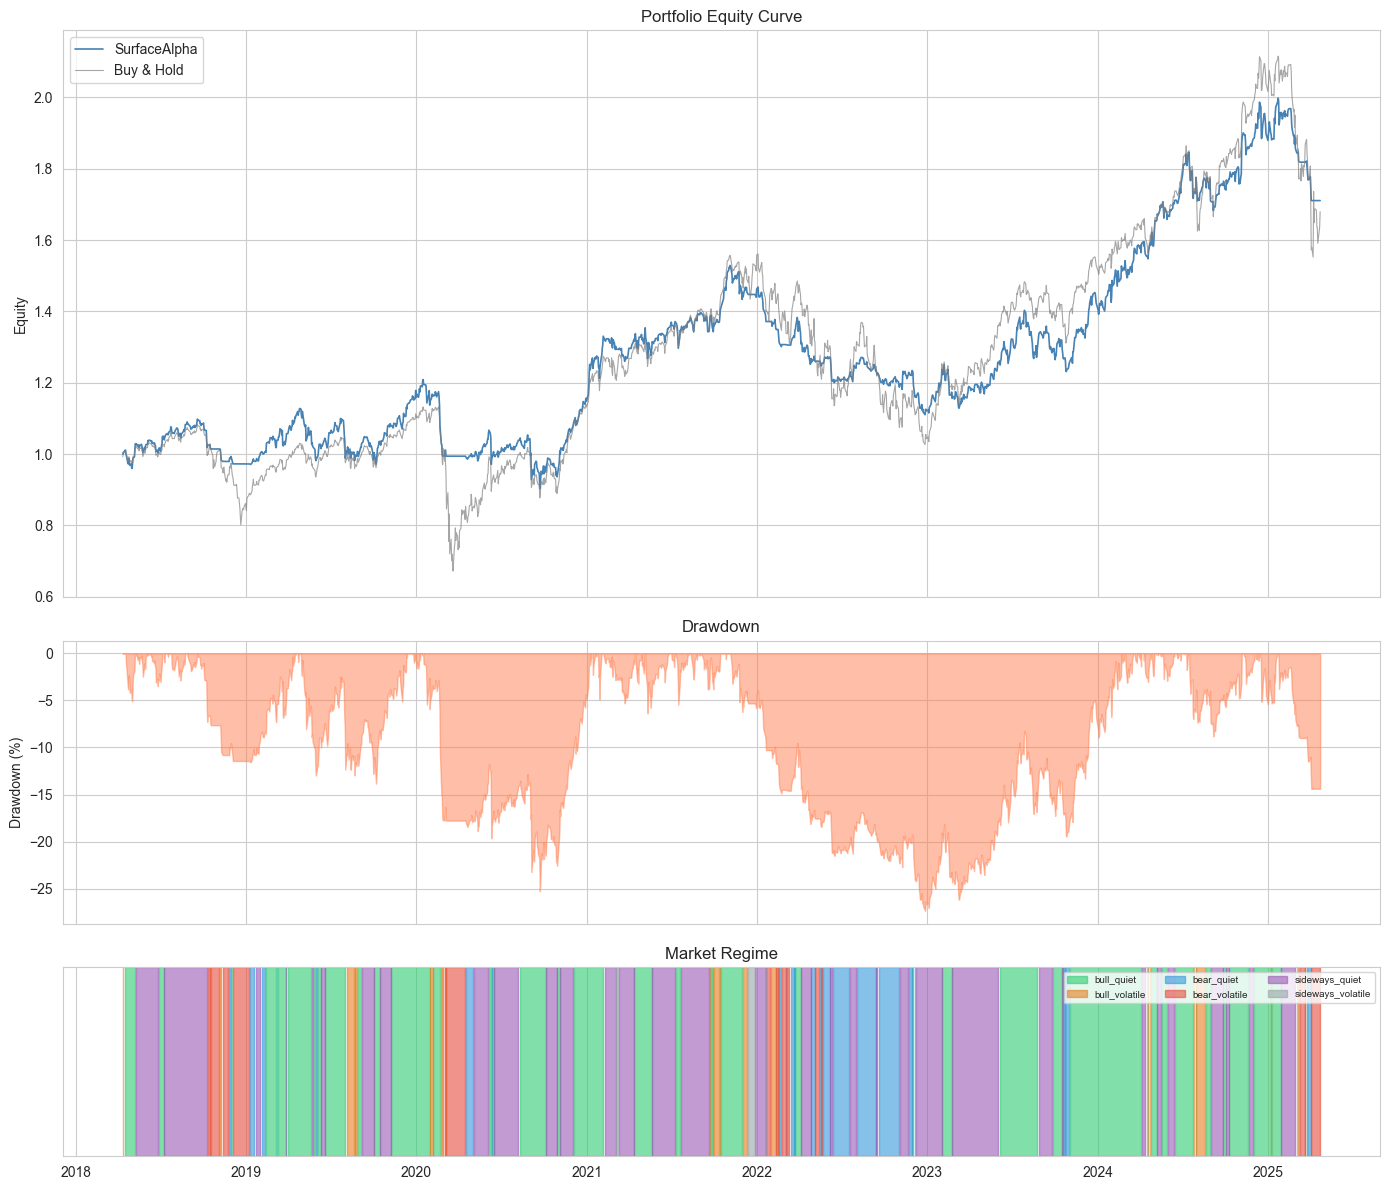

In [15]:
if equity_df is not None:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1.5, 1]})

    ax = axes[0]
    ax.plot(equity_df['date'], equity_df['equity'], color='steelblue', lw=1.2, label='SurfaceAlpha')

    if 'underlying_ret' in equity_df.columns:
        bh_equity = (1 + equity_df['underlying_ret']).cumprod()
        ax.plot(equity_df['date'], bh_equity, color='gray', lw=0.8, alpha=0.7, label='Buy & Hold')

    ax.set_ylabel('Equity')
    ax.set_title('Portfolio Equity Curve')
    ax.legend()

    ax = axes[1]
    if 'drawdown' in equity_df.columns:
        ax.fill_between(equity_df['date'], equity_df['drawdown'] * 100, 0,
                        color='coral', alpha=0.5)
        ax.set_ylabel('Drawdown (%)')
    ax.set_title('Drawdown')

    ax = axes[2]
    if 'regime_name' in equity_df.columns:
        regime_colors = {
            'bull_quiet': '#2ecc71',   'bull_volatile': '#e67e22',
            'bear_quiet': '#3498db',   'bear_volatile': '#e74c3c',
            'sideways_quiet': '#9b59b6', 'sideways_volatile': '#95a5a6',
        }
        for regime, color in regime_colors.items():
            mask = equity_df['regime_name'] == regime
            if mask.any():
                ax.fill_between(equity_df['date'], 0, 1, where=mask,
                                color=color, alpha=0.6, label=regime,
                                transform=ax.get_xaxis_transform())
        ax.set_title('Market Regime')
        ax.legend(loc='upper right', fontsize=7, ncol=3)
        ax.set_yticks([])

    plt.tight_layout()

## 3. Position Sizing Analysis

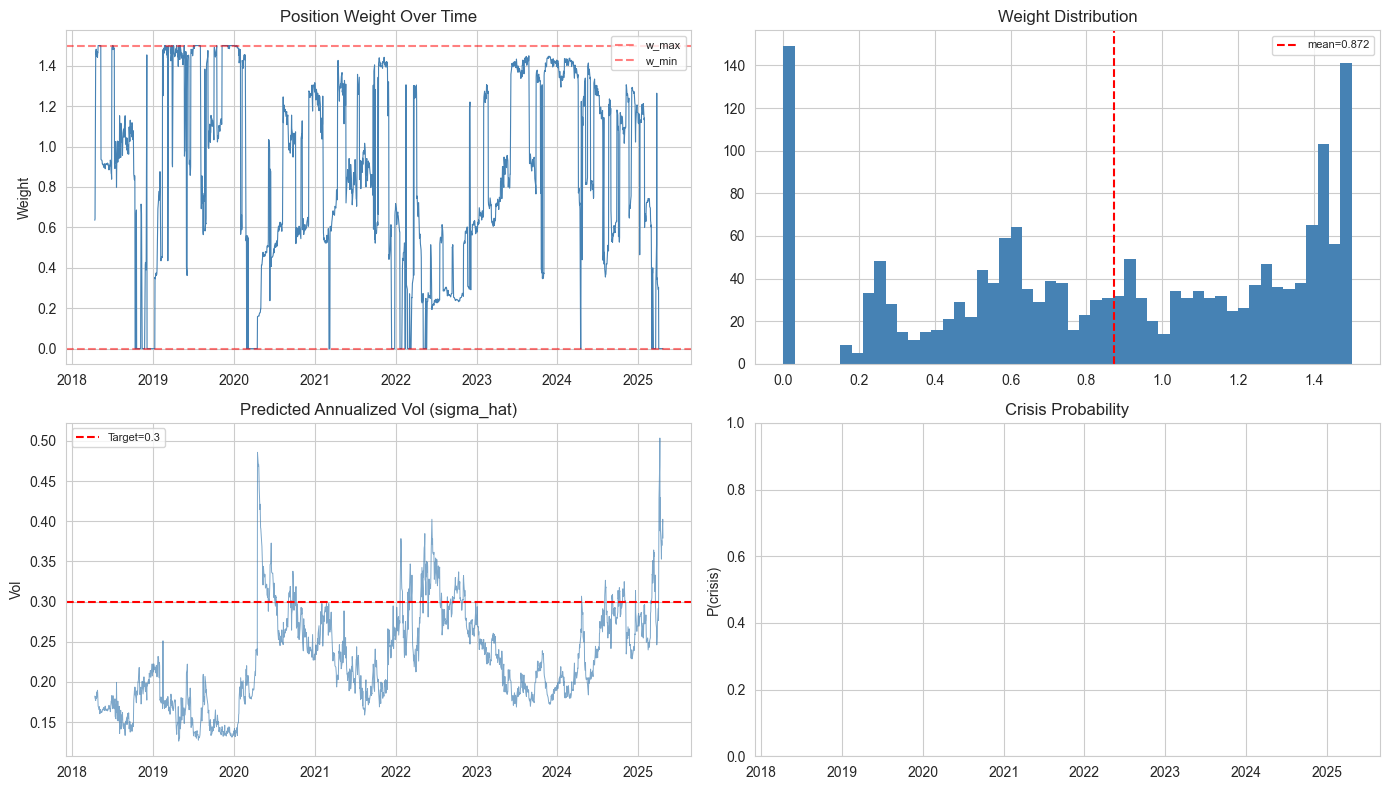

In [16]:
if equity_df is not None and 'weight' in equity_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    ax = axes[0, 0]
    ax.plot(equity_df['date'], equity_df['weight'], color='steelblue', lw=0.8)
    ax.axhline(cfg['backtest']['vol_targeting']['w_max'], color='red', ls='--', alpha=0.5, label='w_max')
    ax.axhline(cfg['backtest']['vol_targeting']['w_min'], color='red', ls='--', alpha=0.5, label='w_min')
    ax.set_title('Position Weight Over Time')
    ax.set_ylabel('Weight')
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    equity_df['weight'].hist(bins=50, ax=ax, color='steelblue', edgecolor='none')
    mean_w = equity_df['weight'].mean()
    ax.axvline(mean_w, color='red', ls='--', label=f'mean={mean_w:.3f}')
    ax.set_title('Weight Distribution')
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    if 'sigma_hat' in equity_df.columns:
        ax.plot(equity_df['date'], equity_df['sigma_hat'], color='steelblue', lw=0.7, alpha=0.7)
        sigma_target = cfg['backtest']['vol_targeting']['sigma_target']
        ax.axhline(sigma_target, color='red', ls='--', label=f'Target={sigma_target}')
        ax.set_title('Predicted Annualized Vol (sigma_hat)')
        ax.set_ylabel('Vol')
        ax.legend(fontsize=8)

    ax = axes[1, 1]
    if 'p_crisis' in equity_df.columns:
        ax.fill_between(equity_df['date'], equity_df['p_crisis'], 0,
                        color='coral', alpha=0.5)
        ax.set_title('Crisis Probability')
        ax.set_ylabel('P(crisis)')
        ax.set_ylim(0, 1)

    plt.tight_layout()

## 4. Per-Regime Performance

Per-regime performance:
                       n  sharpe  avg_weight
bull_quiet         713.0   0.657      1.3404
bull_volatile       90.0   0.653      0.5533
bear_quiet         172.0  -0.085      0.2787
bear_volatile      131.0  -0.850      0.0000
sideways_quiet     640.0   0.808      0.7561
sideways_volatile   18.0  -8.821      0.0000


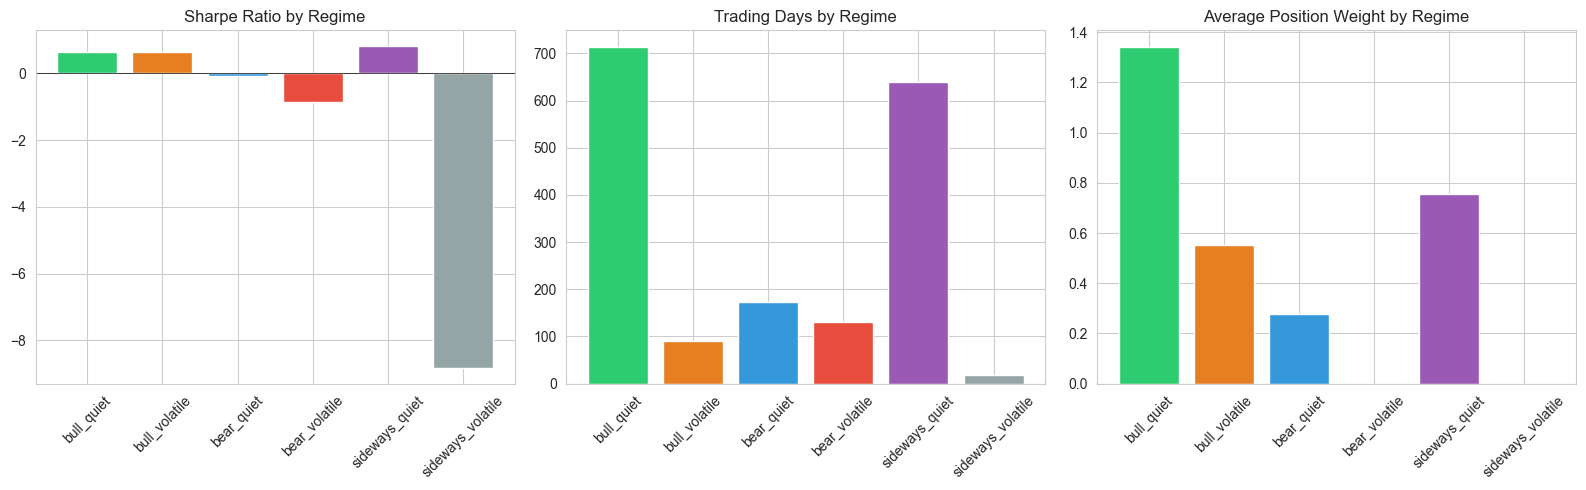

In [17]:
if summary is not None and 'per_regime' in summary:
    per_regime = summary['per_regime']
    regime_perf = pd.DataFrame(per_regime).T
    print("Per-regime performance:")
    print(regime_perf.to_string())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = ['#2ecc71', '#e67e22', '#3498db', '#e74c3c', '#9b59b6', '#95a5a6']

    if 'sharpe' in regime_perf.columns:
        ax = axes[0]
        sharpes = regime_perf['sharpe'].fillna(0)
        ax.bar(sharpes.index, sharpes.values, color=colors[:len(sharpes)])
        ax.axhline(0, color='k', lw=0.5)
        ax.set_title('Sharpe Ratio by Regime')
        ax.tick_params(axis='x', rotation=45)

    if 'n' in regime_perf.columns:
        ax = axes[1]
        counts = regime_perf['n']
        ax.bar(counts.index, counts.values, color=colors[:len(counts)])
        ax.set_title('Trading Days by Regime')
        ax.tick_params(axis='x', rotation=45)

    if 'avg_weight' in regime_perf.columns:
        ax = axes[2]
        weights = regime_perf['avg_weight'].fillna(0)
        ax.bar(weights.index, weights.values, color=colors[:len(weights)])
        ax.set_title('Average Position Weight by Regime')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()

## 5. Benchmark Comparison

In [18]:
if summary is not None and bmark_summary is not None:
    all_strats = {'SurfaceAlpha': {k: v for k, v in summary.items() if k != 'per_regime'}}
    all_strats.update(bmark_summary)

    comp_df = pd.DataFrame(all_strats).T
    display_cols = [c for c in ['ann_return_pct', 'ann_vol_pct', 'sharpe', 'sortino',
                                 'max_drawdown_pct', 'calmar', 'total_return_pct',
                                 'turnover_ann', 'positive_days_pct'] if c in comp_df.columns]
    print("Strategy Comparison:")
    print(comp_df[display_cols].round(4).to_string())

Strategy Comparison:
              ann_return_pct  ann_vol_pct  sharpe  sortino  max_drawdown_pct  calmar  total_return_pct  turnover_ann  positive_days_pct
SurfaceAlpha           8.990       16.196  0.5550   0.6635           -27.372  0.3284            71.056        17.385              49.43
buy_and_hold          10.531       24.922  0.4226   0.5242           -40.659  0.2590            67.925           NaN              52.89
inverse_vol           14.285       27.230  0.5246   0.6964           -40.753  0.3505           109.349         4.198              52.89


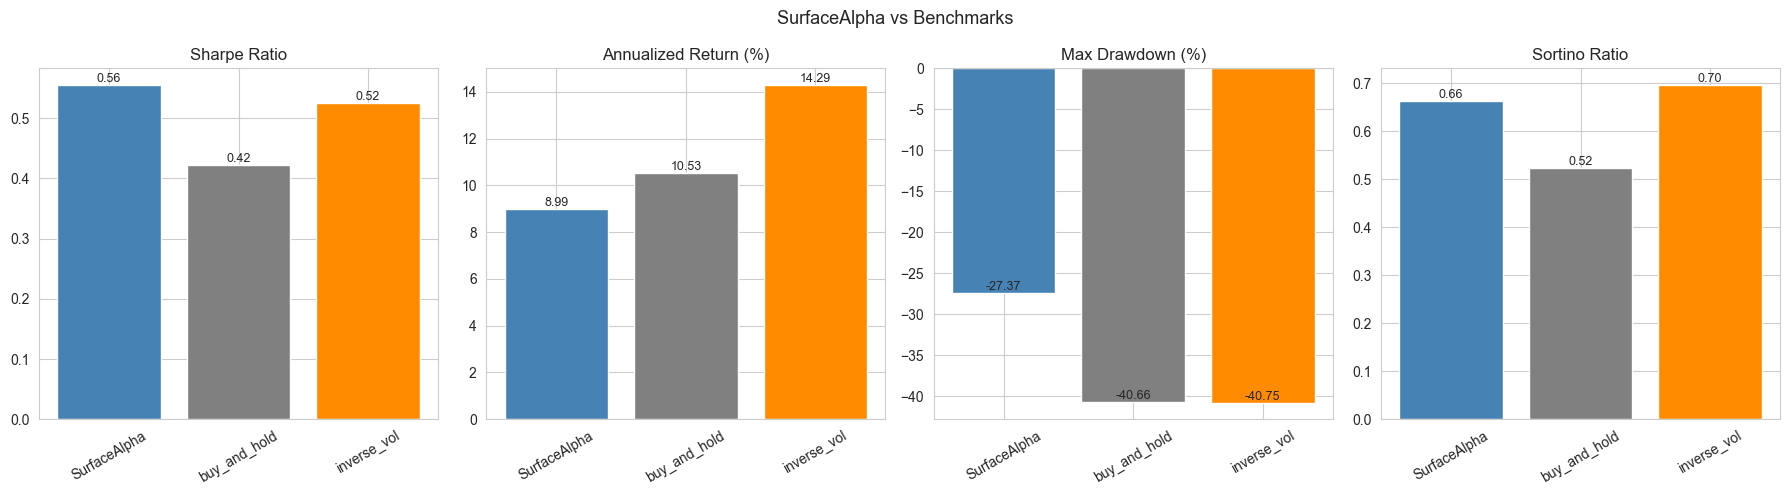

In [19]:
if 'comp_df' in dir():
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    metrics_plot = ['sharpe', 'ann_return_pct', 'max_drawdown_pct', 'sortino']
    titles = ['Sharpe Ratio', 'Annualized Return (%)', 'Max Drawdown (%)', 'Sortino Ratio']
    strat_colors = ['steelblue', 'gray', 'darkorange']

    for ax, metric, title in zip(axes, metrics_plot, titles):
        if metric in comp_df.columns:
            vals = comp_df[metric].fillna(0)
            bars = ax.bar(vals.index, vals.values, color=strat_colors[:len(vals)])
            ax.set_title(title)
            ax.tick_params(axis='x', rotation=30)
            for bar, v in zip(bars, vals.values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('SurfaceAlpha vs Benchmarks', fontsize=13)
    plt.tight_layout()

## 6. Rolling Performance

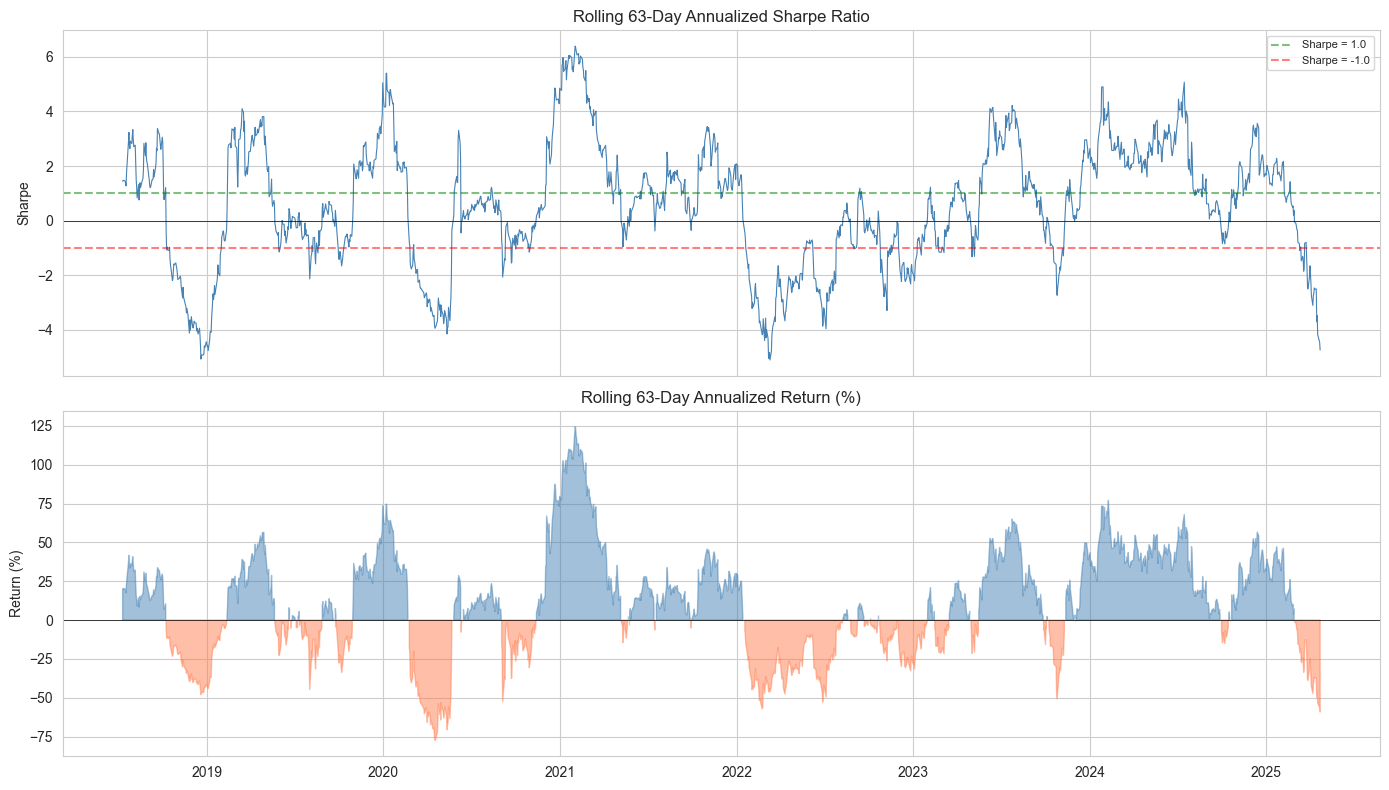

In [20]:
if equity_df is not None and 'strategy_ret' in equity_df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    window = 63  # quarterly
    rolling_mean = equity_df['strategy_ret'].rolling(window).mean() * 252
    rolling_std  = equity_df['strategy_ret'].rolling(window).std() * np.sqrt(252)
    rolling_sharpe = rolling_mean / rolling_std.clip(lower=1e-6)

    ax = axes[0]
    ax.plot(equity_df['date'], rolling_sharpe, color='steelblue', lw=0.8)
    ax.axhline(0,   color='k',     lw=0.5)
    ax.axhline(1.0, color='green', ls='--', alpha=0.5, label='Sharpe = 1.0')
    ax.axhline(-1.0, color='red',  ls='--', alpha=0.5, label='Sharpe = -1.0')
    ax.set_title(f'Rolling {window}-Day Annualized Sharpe Ratio')
    ax.set_ylabel('Sharpe')
    ax.legend(fontsize=8)

    rolling_ret = equity_df['strategy_ret'].rolling(window).sum() * (252 / window)

    ax = axes[1]
    ax.fill_between(equity_df['date'], rolling_ret * 100, 0,
                    where=rolling_ret >= 0, color='steelblue', alpha=0.5)
    ax.fill_between(equity_df['date'], rolling_ret * 100, 0,
                    where=rolling_ret < 0, color='coral', alpha=0.5)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(f'Rolling {window}-Day Annualized Return (%)')
    ax.set_ylabel('Return (%)')

    plt.tight_layout()

## 7. Transaction Cost Analysis

Total transaction costs: 1.0761 (107.61% of initial equity)
Gross strategy return:   1.7054
Net strategy return:     0.6293
Cost drag: 63.1% of gross returns
Config: 5 bps transaction + 2 bps slippage


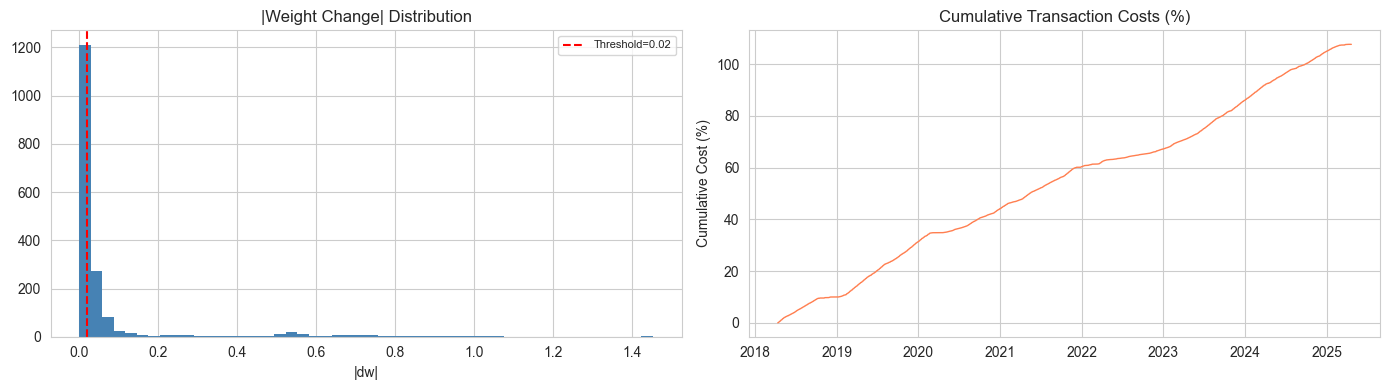

In [21]:
if equity_df is not None and 'cost' in equity_df.columns and 'strategy_ret' in equity_df.columns:
    total_cost  = equity_df['cost'].sum()
    total_gross = equity_df['strategy_ret'].sum() + total_cost
    cost_drag   = total_cost / max(abs(total_gross), 1e-6)

    print(f"Total transaction costs: {total_cost:.4f} ({total_cost * 100:.2f}% of initial equity)")
    print(f"Gross strategy return:   {total_gross:.4f}")
    print(f"Net strategy return:     {equity_df['strategy_ret'].sum():.4f}")
    print(f"Cost drag: {cost_drag:.1%} of gross returns")
    print(f"Config: {cfg['backtest']['costs']['transaction_cost_bps']} bps transaction + "
          f"{cfg['backtest']['costs']['slippage_bps']} bps slippage")

    weight_changes = equity_df['weight'].diff().dropna()
    rebalance_threshold = cfg['backtest']['rebalance']['min_trade_threshold']

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(weight_changes.abs(), bins=50, color='steelblue', edgecolor='none')
    axes[0].axvline(rebalance_threshold, color='red', ls='--',
                    label=f'Threshold={rebalance_threshold}')
    axes[0].set_title('|Weight Change| Distribution')
    axes[0].set_xlabel('|dw|')
    axes[0].legend(fontsize=8)

    axes[1].plot(equity_df['date'], equity_df['cost'].cumsum() * 100, color='coral', lw=1)
    axes[1].set_title('Cumulative Transaction Costs (%)')
    axes[1].set_ylabel('Cumulative Cost (%)')

    plt.tight_layout()

## 8. Overlay Logic Decomposition

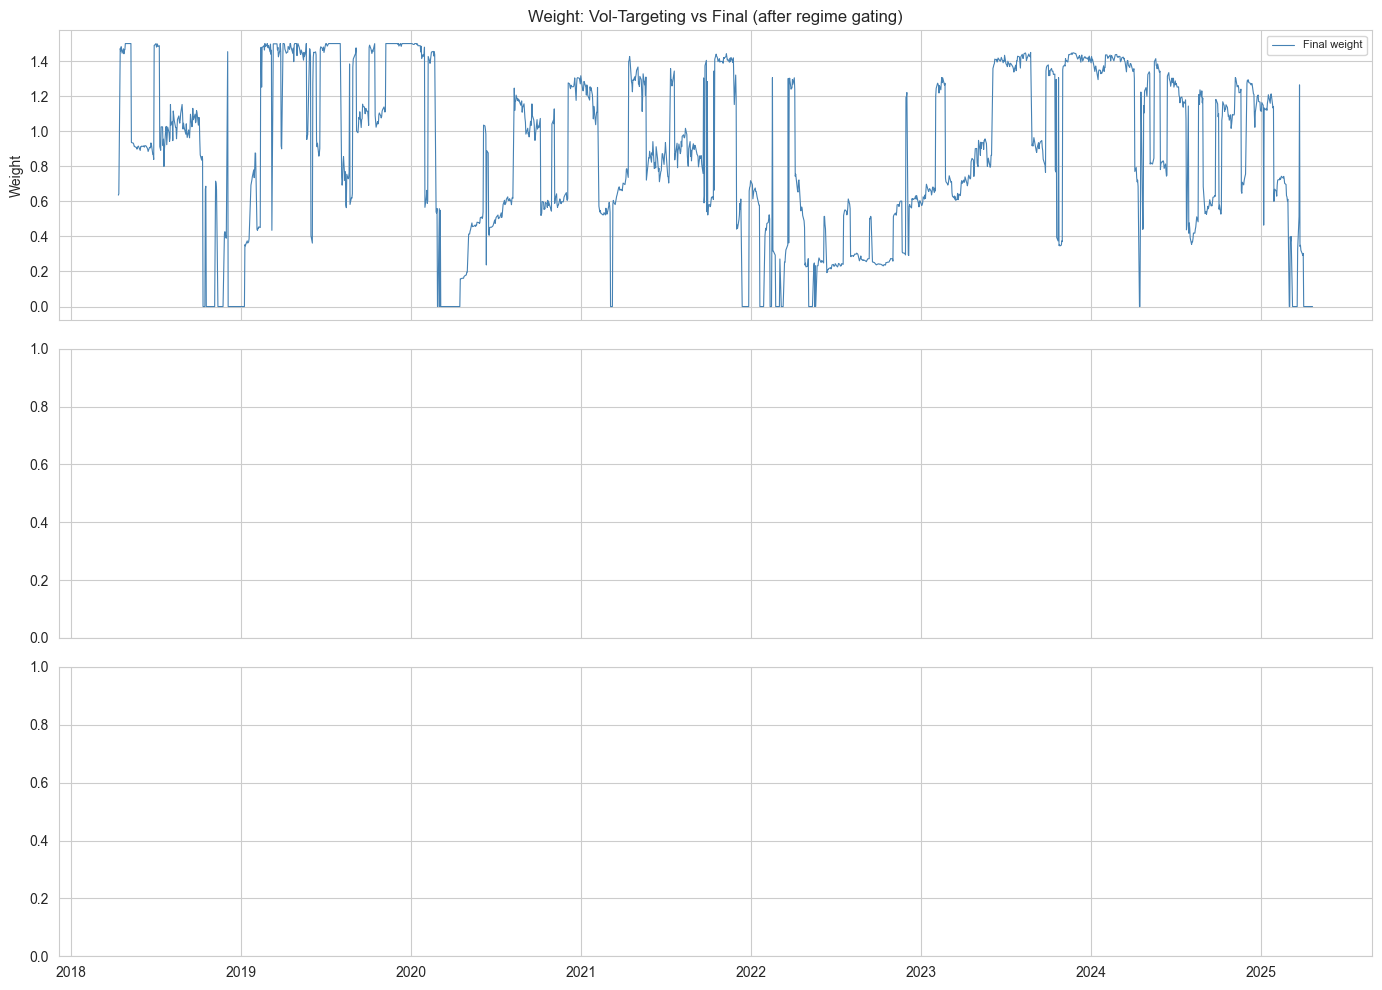

In [24]:
pos_path = bt_dir / 'position_history.csv'
if pos_path.exists():
    pos_df = pd.read_csv(pos_path, parse_dates=['date'])

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    ax = axes[0]
    if 'w_vol_target' in pos_df.columns:
        ax.plot(pos_df['date'], pos_df['w_vol_target'], color='gray', lw=0.6, alpha=0.7, label='Vol-target only')
    ax.plot(equity_df['date'], equity_df['weight'], color='steelblue', lw=0.8, label='Final weight')
    ax.set_title('Weight: Vol-Targeting vs Final (after regime gating)')
    ax.set_ylabel('Weight')
    ax.legend(fontsize=8)

    ax = axes[1]
    if 'regime_size' in pos_df.columns:
        ax.plot(pos_df['date'], pos_df['regime_size'], color='darkorange', lw=0.8)
        ax.set_title('Regime Position Size Multiplier')
        ax.set_ylabel('Multiplier')
        ax.set_ylim(-0.05, 1.15)

    ax = axes[2]
    if 'adx_override' in pos_df.columns:
        adx_events = pos_df['adx_override'].astype(float)
        ax.fill_between(pos_df['date'], adx_events, 0, color='coral', alpha=0.5)
        n_overrides = int(adx_events.sum())
        ax.set_title(f'ADX Override Events ({n_overrides} of {len(pos_df)} days = {n_overrides/len(pos_df):.1%})')
        ax.set_ylabel('Override Active')
        ax.set_ylim(-0.05, 1.15)

    plt.tight_layout()
else:
    print(f"position_history.csv not found at {pos_path}")